# 01 — Feature EDA

Before touching any model I want to sanity-check the feature panel that `scripts/build_features.py` produced: coverage, distributional shape, how much information overlap exists between features, and how each one ranks against the 21-day forward cross-sectional return on its own.

**Sample.** 502 current S&P 500 constituents, 2015-01-02 → 2025-07-30. Survivorship bias acknowledged — see repo README.

What I'm looking for in a "useful" feature: reasonable coverage (not 80% NaN outside the warm-up), a Spearman IC against `fwd_rank_21d` with mean > 0 and IC-IR > ~0.1, and no near-duplication of something already in the set (mean cross-sectional correlation below ~0.9).

IC values will be modest — a single monthly-horizon feature on liquid US large-caps rarely clears IC = 0.05. The model's job is to combine them, so the EDA question is really "does this feature add anything the others don't already have?"

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROC_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
# pick the newest feature parquet
candidates = sorted(PROC_DIR.glob("features_*.parquet"))
assert candidates, "Run scripts/build_features.py first."
path = candidates[-1]
print("loading", path.name)

df = pd.read_parquet(path)
df["date"] = pd.to_datetime(df["date"])
FEATURE_COLS = [c for c in df.columns if c not in (
    "date", "symbol", "fwd_ret_21d", "fwd_rank_21d",
)]
print(f"rows: {len(df):,}   features: {len(FEATURE_COLS)}")
df.head(3)

loading features_2015-01-01_2025-07-31_h21.parquet


rows: 1,291,123   features: 13


,date,symbol,mom_12_1,reversal_1w,low_vol_60,size_adv_60,ret_21d,ret_63d,ret_126d,ret_252d,vol_20d,vol_60d,rsi_14,macd_hist,volume_z_60,fwd_ret_21d,fwd_rank_21d
0,2015-01-02,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,-0.023176,0.277056
1,2015-01-02,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.085247,0.904762
2,2015-01-02,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,-0.057325,0.125541


## 1. Coverage

How many symbols do we have at each date, and how much of each feature survives the warm-up period?

date range: 2015-01-02 → 2025-07-30
symbols/date — median: 488   min: 462   max: 502


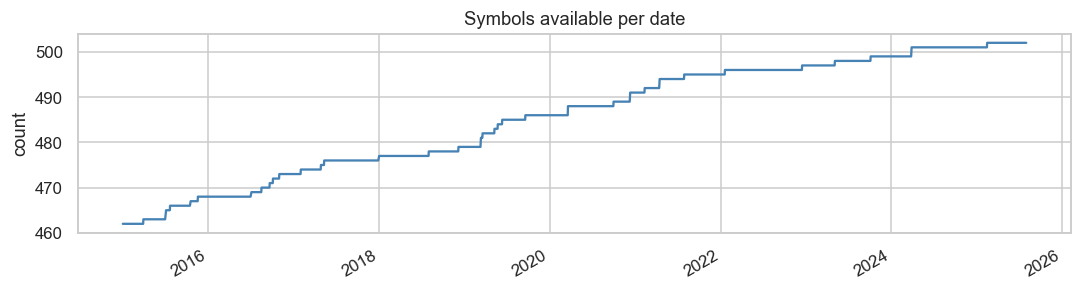

In [3]:
per_date = df.groupby("date")["symbol"].nunique()
print(f"date range: {per_date.index.min().date()} → {per_date.index.max().date()}")
print(f"symbols/date — median: {per_date.median():.0f}   min: {per_date.min()}   max: {per_date.max()}")

fig, ax = plt.subplots(figsize=(10, 2.8))
per_date.plot(ax=ax, color="steelblue")
ax.set_title("Symbols available per date")
ax.set_ylabel("count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [4]:
# feature non-NaN coverage as a % of total rows, and as a % of rows after an
# arbitrary 300-day warmup (ret_252d's warmup dominates otherwise)
warmup_cutoff = df["date"].unique()
warmup_cutoff = np.sort(warmup_cutoff)[300]
post = df[df["date"] >= warmup_cutoff]

coverage = pd.DataFrame({
    "all":          df[FEATURE_COLS].notna().mean(),
    "post_warmup":  post[FEATURE_COLS].notna().mean(),
}).round(3)
coverage.sort_values("post_warmup")

,all,post_warmup
mom_12_1,0.894,0.991
ret_252d,0.902,0.992
ret_126d,0.951,0.996
low_vol_60,0.977,0.998
ret_63d,0.976,0.998
size_adv_60,0.977,0.998
volume_z_60,0.977,0.998
vol_60d,0.977,0.998
vol_20d,0.992,0.999
ret_21d,0.992,0.999


## 2. Distributions

Each feature plotted over the full panel. Features with heavy tails (`size_adv_60`, return series) are shown on a signed-log axis so the bulk of the distribution is visible rather than crushed by extreme outliers.

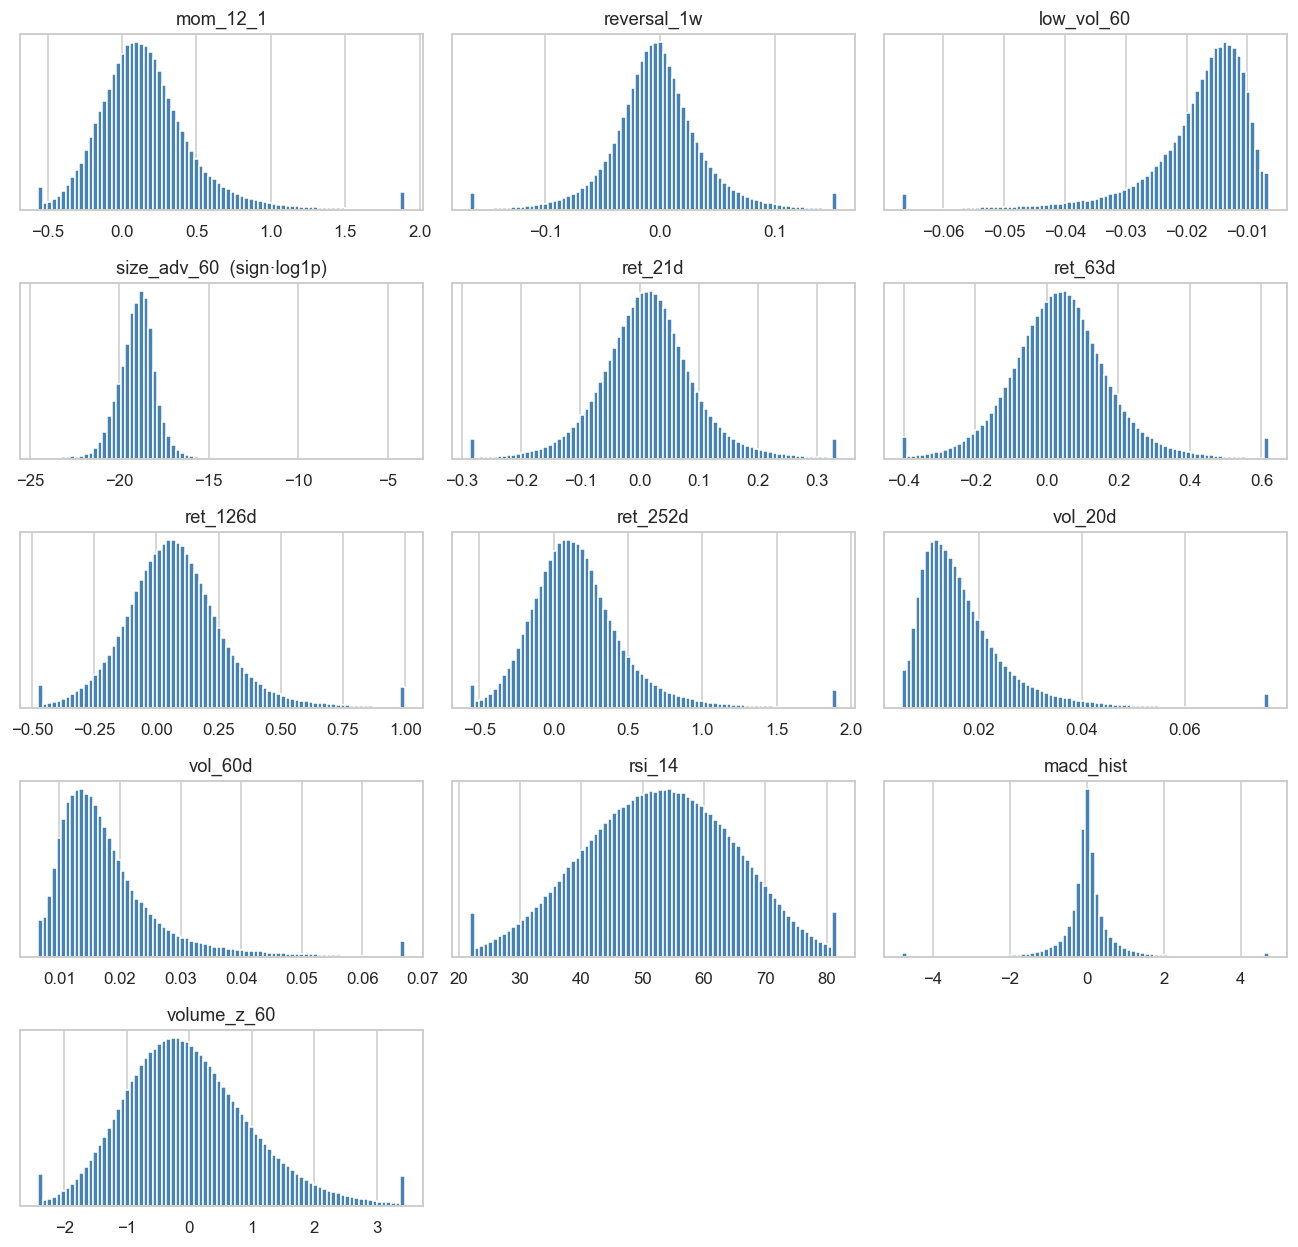

In [5]:
def _sym_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

n = len(FEATURE_COLS)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.3 * nrows))
axes = axes.flatten()

SIGNED_LOG = {"size_adv_60"}

for ax, col in zip(axes, FEATURE_COLS):
    vals = df[col].dropna()
    if col in SIGNED_LOG:
        ax.hist(_sym_log(vals), bins=80, color="steelblue")
        ax.set_title(f"{col}  (sign·log1p)")
    else:
        # clip to 0.5–99.5 percentile so a few outliers don't flatten the shape
        lo, hi = vals.quantile([0.005, 0.995])
        ax.hist(vals.clip(lo, hi), bins=80, color="steelblue")
        ax.set_title(col)
    ax.set_yticks([])

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_feature_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Feature overlap

How correlated are the features cross-sectionally? Near-duplicate features give linear models a collinearity problem and give tree models redundant splits that fragment SHAP importance without adding information.

I compute the cross-sectional Spearman correlation between every feature pair on each date, then average across dates. This matches how the downstream ranker sees the features — relative ordering within a single day, not time-series levels.

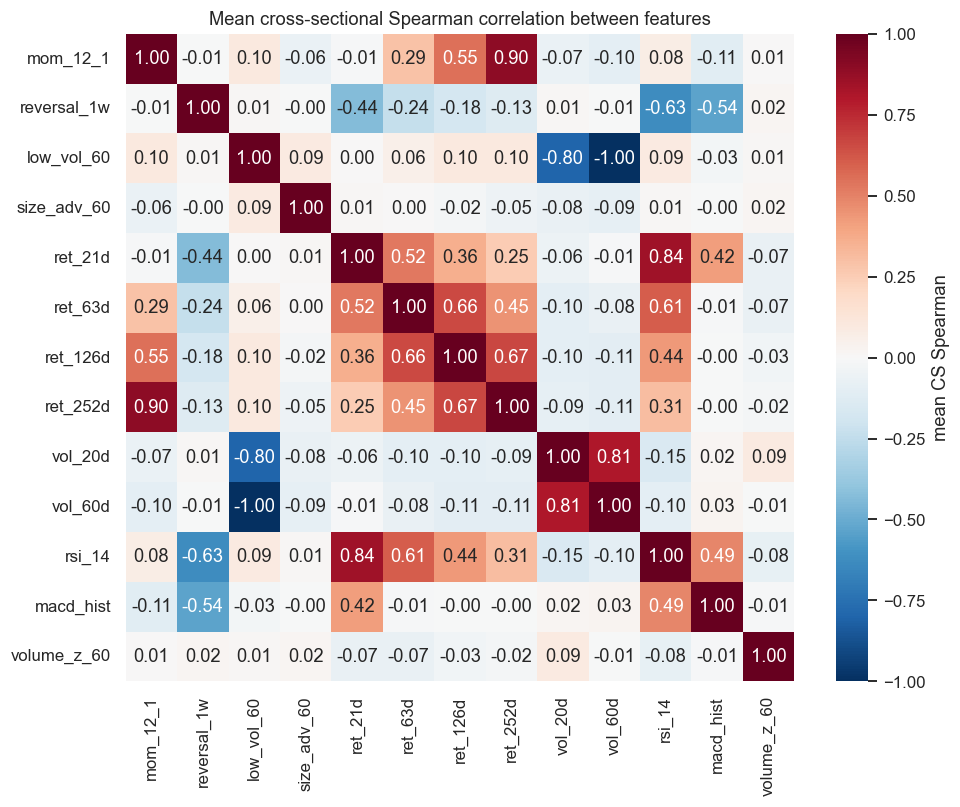

In [6]:
def mean_crosssectional_corr(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    acc = np.zeros((len(cols), len(cols)))
    n_dates = 0
    for _, g in data.groupby("date"):
        sub = g[cols].dropna(how="any")
        if len(sub) < 20:
            continue
        acc += sub.rank().corr().values
        n_dates += 1
    return pd.DataFrame(acc / n_dates, index=cols, columns=cols)

corr = mean_crosssectional_corr(df, FEATURE_COLS)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "mean CS Spearman"})
ax.set_title("Mean cross-sectional Spearman correlation between features")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_feature_corr.png", dpi=130, bbox_inches="tight")
plt.show()

In [7]:
# flag near-duplicate pairs (|ρ| > 0.9) for the notebook write-up
pairs = []
for i, a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.9:
            pairs.append((a, b, round(float(r), 3)))
pd.DataFrame(pairs, columns=["feature_a", "feature_b", "corr"])

,feature_a,feature_b,corr
0,low_vol_60,vol_60d,-0.999


## 4. Single-feature IC

For each feature, per-date cross-sectional Spearman rank correlation with `fwd_rank_21d` gives an IC time series. The summary stats I care about:

- **mean IC** — average directional edge per date (positive = useful signal).
- **IC-IR** — mean / std, the risk-adjusted edge per date.
- **t-stat** — IC-IR × √N. IC is serially correlated so this is a heuristic, not a p-value, but anything below ~2 I treat as noise.
- **hit rate** — fraction of dates with IC > 0.

In [8]:
def per_date_ic(data: pd.DataFrame, feature: str, target: str = "fwd_rank_21d") -> pd.Series:
    def _corr(g):
        sub = g[[feature, target]].dropna()
        if len(sub) < 20:
            return np.nan
        return sub[feature].rank().corr(sub[target])
    return data.groupby("date").apply(_corr, include_groups=False)

ic_frames = {}
for col in FEATURE_COLS:
    ic_frames[col] = per_date_ic(df, col)
ic_df = pd.DataFrame(ic_frames)
ic_df.tail(3)

,mom_12_1,reversal_1w,low_vol_60,size_adv_60,ret_21d,ret_63d,ret_126d,ret_252d,vol_20d,vol_60d,rsi_14,macd_hist,volume_z_60
date,,,,,,,,,,,,,
2025-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
rows = []
for col in FEATURE_COLS:
    s = ic_df[col].dropna()
    if len(s) == 0:
        continue
    mean = s.mean()
    std = s.std()
    ir = mean / std if std > 0 else np.nan
    tstat = ir * np.sqrt(len(s)) if pd.notna(ir) else np.nan
    rows.append({
        "feature":    col,
        "mean_ic":    round(mean, 4),
        "ic_std":     round(std, 4),
        "ic_ir":      round(ir, 3) if pd.notna(ir) else np.nan,
        "t_stat":     round(tstat, 2) if pd.notna(tstat) else np.nan,
        "hit_rate":   round((s > 0).mean(), 3),
        "n_dates":    int(len(s)),
    })
ic_summary = pd.DataFrame(rows).sort_values("ic_ir", ascending=False).reset_index(drop=True)
ic_summary

,feature,mean_ic,ic_std,ic_ir,t_stat,hit_rate,n_dates
0,size_adv_60,0.0159,0.0994,0.160,8.11,0.585,2579
1,vol_60d,0.0290,0.2374,0.122,6.20,0.519,2578
2,vol_20d,0.0249,0.2151,0.116,5.92,0.518,2618
3,reversal_1w,0.0125,0.1659,0.075,3.87,0.533,2633
4,volume_z_60,0.0036,0.0760,0.047,2.38,0.524,2579
5,mom_12_1,-0.0020,0.2086,-0.009,-0.46,0.520,2365
6,ret_126d,-0.0068,0.1969,-0.034,-1.73,0.514,2512
7,ret_252d,-0.0094,0.2137,-0.044,-2.14,0.506,2386
8,macd_hist,-0.0089,0.1375,-0.064,-3.31,0.479,2637
9,ret_63d,-0.0156,0.1865,-0.084,-4.24,0.502,2575


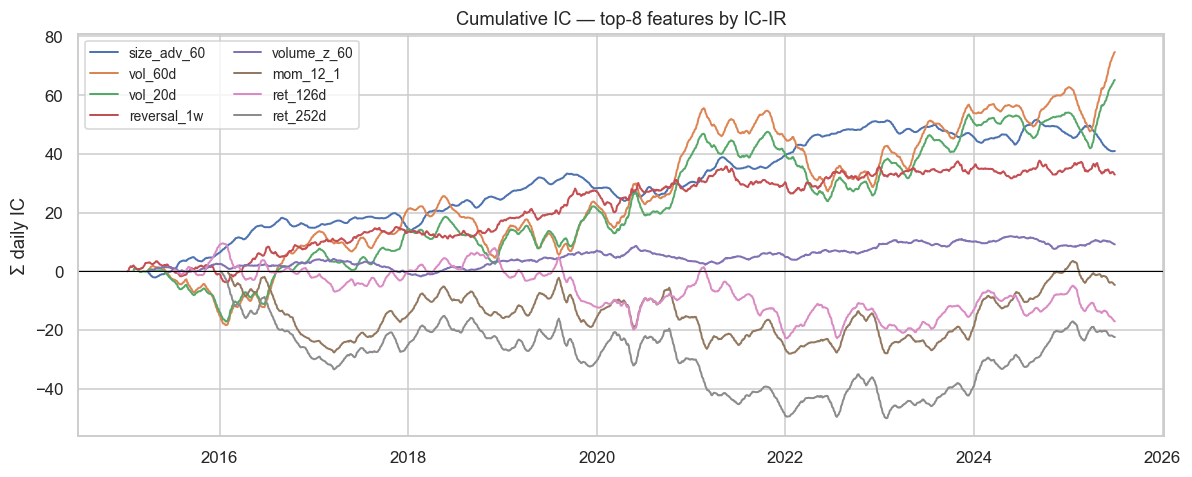

In [10]:
# cumulative IC — flat-trending features are signals that persist; jagged
# cumulative paths mean the factor only works in specific regimes.
top = ic_summary.head(8)["feature"].tolist()
cum = ic_df[top].cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
for col in top:
    ax.plot(cum.index, cum[col], label=col, linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Cumulative IC — top-8 features by IC-IR")
ax.set_ylabel("Σ daily IC")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_feature_cumulative_ic.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Takeaways

### 5.1 Coverage is not a constraint.
Every feature is ≥ 99% populated after the 300-day warm-up window. The only pre-warm-up gaps trace to `ret_252d` and `mom_12_1`, which mechanically need 252 + 21 days of history. Nothing to drop on coverage grounds.

### 5.2 `low_vol_60` and `vol_60d` are the same feature.
Their mean cross-sectional Spearman is **−0.999** — by construction. `low_vol_60` is the pct-return rolling std sign-flipped; `vol_60d` is the log-return rolling std raw. At daily frequency log-return ≈ pct-return to three decimals. **I'm dropping `low_vol_60` from the model feature set.** Keeping both would split SHAP importance arbitrarily across the pair and give the linear baselines a nasty collinearity hit. `vol_60d` is the more natural axis — raw volatility level, let the model decide the sign.

### 5.3 The single-feature IC is revealing, but not always in the expected direction.

**Features that earn their place** (IC-IR > 0.1, t-stat > 5):
- `size_adv_60` (IC-IR **+0.16**): the strongest single factor. Small-ADV names out-rank large-ADV names — the liquidity/size premium, still alive in the S&P 500 post-2015.
- `vol_60d` and `vol_20d` (IC-IR ≈ +0.12): what surprised me here is the sign. **High-vol names outperform.** The textbook low-vol anomaly is reversed in this sample. That could be a post-2015 growth/high-beta leadership effect, or it could be survivorship — failed high-vol names have already left the current constituent list. Worth retesting on a sector-neutral basis.
- `reversal_1w` (IC-IR +0.08): short-horizon mean reversion survives, though modestly.

**Features that are dead** (|IC-IR| < 0.05):
- `mom_12_1`: mean IC effectively zero (−0.002, t = −0.5). The 12-1 momentum factor has decayed to noise on S&P 500 post-2015. This matches `classic-factors` notebook 01 directly — useful corroboration across two independent calculations.
- `ret_126d`, `volume_z_60`: weak / indeterminate.

**Features with the wrong sign vs. textbook** (significantly negative IC):
- `rsi_14` (IC-IR −0.10), `ret_21d` (−0.09), `macd_hist` (−0.06), `ret_63d` (−0.08). All conventional momentum-direction features come in negative at the one-month forward horizon. On modern large-cap US, they are reading as reversal signals. A tree model will pick the right split direction automatically. What I will not do is silently flip the signs to make the IC table look cleaner — I'll keep them raw and let the regularised weights sort it out.

### 5.4 The cumulative-IC chart matters more than the headline number.
A +0.16 IC-IR from `size_adv_60` means nothing if it all came from one COVID window. The cumulative IC panel is where I want to check whether the signal is a steady structural drift or a few regime jumps. The walk-forward in notebook 02 partitions the same four regimes as `classic-factors` so I can compare per-regime model IC directly.

### 5.5 Open questions going into modelling.
- **Size × vol interaction.** The two strongest signals are small-ADV and high-vol. Are they orthogonal, or is the model just re-learning "small, volatile" as one composite axis? A 2×2 quintile return table (size × vol) before training would clarify.
- **Momentum residualisation.** Given `mom_12_1` ≈ 0 IC, residualising other features against it gains nothing — the Grinold argument assumes a dominant momentum factor, and there isn't one here.
- **Feature set for the linear baseline.** Probably keep `size_adv_60`, `vol_60d`, `reversal_1w`, `volume_z_60`, and drop the short-horizon returns and RSI. They are informative only after a sign flip that collides with `reversal_1w`. Tree model keeps the full set minus `low_vol_60`.